# 03 — Modelado: Baseline, XGBoost, Optuna y SHAP
## Aircraft Engine Predictive Maintenance · NASA C-MAPSS Dataset

**Objetivo de este notebook:** entrenar y evaluar el modelo final.

El recorrido que vamos a hacer:
1. Cargar los datos procesados
2. Entrenar un **baseline** con Regresión Logística
3. Entrenar **XGBoost** y comparar contra el baseline
4. Optimizar XGBoost con **Optuna** (optimización bayesiana de hiperparámetros)
5. Explicar el modelo final con **SHAP**
6. Guardar el modelo entrenado

---

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve
)

import xgboost as xgb
import optuna
import shap

# Silenciar logs verbosos de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')

print('Librerías cargadas correctamente ✅')

Librerías cargadas correctamente ✅


## 2. Cargar los datos procesados

Cargamos los archivos que guardamos en el notebook de preprocesamiento.

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape} — {y_train.sum()} casos en riesgo ({y_train.mean()*100:.1f}%)')
print(f'y_test:  {y_test.shape} — {y_test.sum()} casos en riesgo ({y_test.mean()*100:.1f}%)')

X_train: (128287, 42)
X_test:  (32072, 42)
y_train: (128287,) — 17016 casos en riesgo (13.3%)
y_test:  (32072,) — 4254 casos en riesgo (13.3%)


---
# PASO 1 — Baseline: Regresión Logística

Empezamos con el modelo más simple posible. Esto nos da un punto de referencia:
si los modelos complejos no superan esto, algo va mal.

In [3]:
# Entrenamos la Regresión Logística
# class_weight='balanced' compensa el desbalanceo de clases (14.5% en riesgo)
baseline = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

baseline.fit(X_train, y_train)

# Predicciones
y_pred_baseline = baseline.predict(X_test)
y_proba_baseline = baseline.predict_proba(X_test)[:, 1]

# Métricas
auc_baseline = roc_auc_score(y_test, y_proba_baseline)
recall_baseline = recall_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline)

print('BASELINE — Regresión Logística')
print(f'  AUC-ROC:   {auc_baseline:.4f}')
print(f'  Recall:    {recall_baseline:.4f}')
print(f'  Precision: {precision_baseline:.4f}')

BASELINE — Regresión Logística
  AUC-ROC:   0.9884
  Recall:    0.9579
  Precision: 0.7001


---
# PASO 2 — XGBoost (parámetros por defecto)

Ahora entrenamos XGBoost, nuestro modelo principal, sin optimizar todavía.
Esto nos dice cuánto mejora respecto al baseline antes de optimizar nada.

In [4]:
# Calculamos scale_pos_weight para compensar el desbalanceo
# Fórmula: número de negativos / número de positivos
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight calculado: {scale_pos_weight:.2f}')
print(f'(Esto le dice al modelo que un error en clase "en riesgo" pesa {scale_pos_weight:.2f}x más)\n')

# Entrenamos XGBoost con parámetros por defecto
xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

xgb_base.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_base.predict(X_test)
y_proba_xgb = xgb_base.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)

print('XGBOOST (sin optimizar)')
print(f'  AUC-ROC:   {auc_xgb:.4f}')
print(f'  Recall:    {recall_xgb:.4f}')
print(f'  Precision: {precision_xgb:.4f}')

print(f'\n📌 Mejora vs baseline en AUC-ROC: {(auc_xgb - auc_baseline)*100:+.2f} puntos')

scale_pos_weight calculado: 6.54
(Esto le dice al modelo que un error en clase "en riesgo" pesa 6.54x más)

XGBOOST (sin optimizar)
  AUC-ROC:   0.9922
  Recall:    0.9415
  Precision: 0.7795

📌 Mejora vs baseline en AUC-ROC: +0.39 puntos


---
# PASO 3 — Optimización bayesiana con Optuna

**¿Qué hace Optuna?**

XGBoost tiene muchos parámetros (profundidad del árbol, learning rate, número de árboles...).
Probarlos todos a mano es imposible. Optuna prueba decenas de combinaciones de forma
inteligente — cada intento aprende del anterior para acercarse más rápido al óptimo
(a diferencia de probar combinaciones al azar).

Usamos **cross-validation estratificada** dentro de cada prueba para que el resultado
sea robusto y no dependa de un único split de datos.

> **Nota:** en este entorno de ejecución (1 núcleo de CPU) reducimos la búsqueda a 15 pruebas con validación cruzada de 3 folds (en vez de 50 pruebas / 5 folds) para que terminara en un tiempo razonable. Si lo reejecutas en una máquina con más núcleos, puedes subir `n_trials` y `n_splits` a los valores originales para una búsqueda más exhaustiva.

In [5]:
def objetivo(trial):
    """
    Función que Optuna intenta maximizar.
    Cada 'trial' es una combinación de parámetros distinta.
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'auc',
        'random_state': 42
    }
    
    modelo = xgb.XGBClassifier(**params)
    
    # Cross-validation estratificada de 5 folds
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc')
    
    return scores.mean()


# Creamos el estudio de Optuna (queremos MAXIMIZAR el AUC-ROC)
#estudio = optuna.create_study(direction='maximize')
estudio = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))

# Ejecutamos 50 pruebas (cada una entrena 5 modelos por el cross-validation)
# Esto puede tardar varios minutos
print('Iniciando optimización con Optuna (15 pruebas, cv=3 — reducido por limitación de hardware de este entorno)...')
print('Esto puede tardar varios minutos, ten paciencia.\n')

estudio.optimize(objetivo, n_trials=15, show_progress_bar=True)


print(f'\n✅ Optimización completada')
print(f'Mejor AUC-ROC (cross-validation): {estudio.best_value:.4f}')
print(f'\nMejores parámetros encontrados:')
for param, valor in estudio.best_params.items():
    print(f'  {param}: {valor}')

Iniciando optimización con Optuna (15 pruebas, cv=3 — reducido por limitación de hardware de este entorno)...
Esto puede tardar varios minutos, ten paciencia.



Best trial: 0. Best value: 0.992354: 100%|██████████| 15/15 [01:20<00:00,  5.34s/it]


✅ Optimización completada
Mejor AUC-ROC (cross-validation): 0.9924

Mejores parámetros encontrados:
  n_estimators: 175
  max_depth: 10
  learning_rate: 0.1205712628744377
  subsample: 0.8394633936788146
  colsample_bytree: 0.6624074561769746
  min_child_weight: 2


In [6]:
# Entrenamos el modelo FINAL con los mejores parámetros encontrados
mejores_params = estudio.best_params.copy()
mejores_params['scale_pos_weight'] = scale_pos_weight
mejores_params['eval_metric'] = 'auc'
mejores_params['random_state'] = 42

modelo_final = xgb.XGBClassifier(**mejores_params)
modelo_final.fit(X_train, y_train)

# Predicciones del modelo final
y_pred_final = modelo_final.predict(X_test)
y_proba_final = modelo_final.predict_proba(X_test)[:, 1]

# Métricas finales
auc_final = roc_auc_score(y_test, y_proba_final)
recall_final = recall_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

print('MODELO FINAL — XGBoost + Optuna')
print(f'  AUC-ROC:   {auc_final:.4f}')
print(f'  Recall:    {recall_final:.4f}')
print(f'  Precision: {precision_final:.4f}')
print(f'  F1-Score:  {f1_final:.4f}')

MODELO FINAL — XGBoost + Optuna
  AUC-ROC:   0.9931
  Recall:    0.9156
  Precision: 0.8460
  F1-Score:  0.8794


## Comparativa de los 3 modelos

                   Modelo  AUC-ROC   Recall  Precision
Baseline (Reg. Logística) 0.988362 0.957922   0.700052
  XGBoost (sin optimizar) 0.992241 0.941467   0.779486
         XGBoost + Optuna 0.993094 0.915609   0.846003


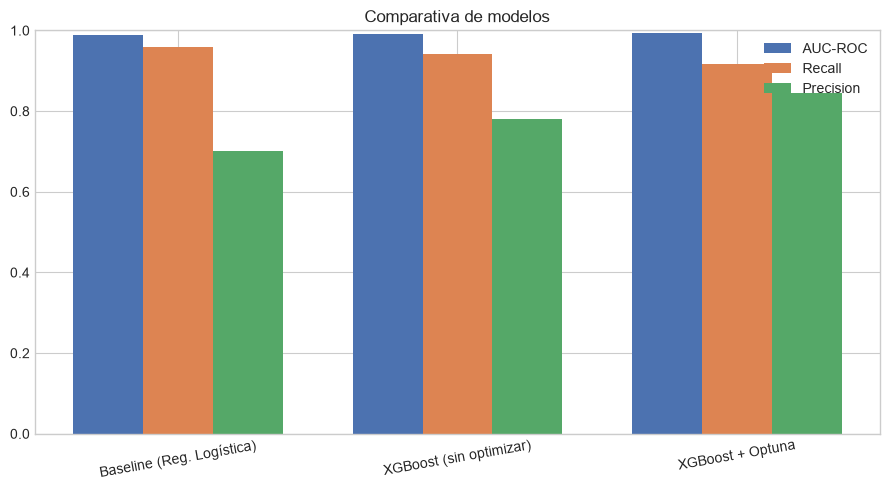


📌 Mejora total vs baseline en AUC-ROC: +0.47 puntos


In [7]:
comparativa = pd.DataFrame({
    'Modelo': ['Baseline (Reg. Logística)', 'XGBoost (sin optimizar)', 'XGBoost + Optuna'],
    'AUC-ROC': [auc_baseline, auc_xgb, auc_final],
    'Recall': [recall_baseline, recall_xgb, recall_final],
    'Precision': [precision_baseline, precision_xgb, precision_final]
})

print(comparativa.to_string(index=False))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparativa))
width = 0.25

ax.bar(x - width, comparativa['AUC-ROC'], width, label='AUC-ROC', color='#4C72B0')
ax.bar(x, comparativa['Recall'], width, label='Recall', color='#DD8452')
ax.bar(x + width, comparativa['Precision'], width, label='Precision', color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(comparativa['Modelo'], rotation=10)
ax.set_ylim(0, 1)
ax.set_title('Comparativa de modelos')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig5_comparativa_modelos.png', dpi=150)
plt.show()

print(f"\n📌 Mejora total vs baseline en AUC-ROC: {(auc_final - auc_baseline)*100:+.2f} puntos")

## Curva ROC y Matriz de Confusión del modelo final

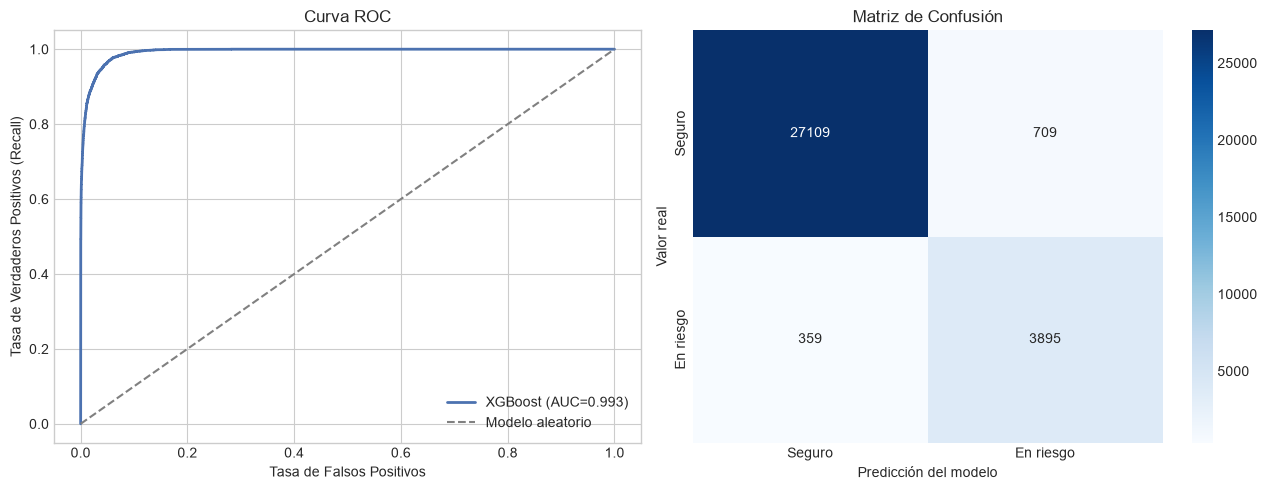

📌 Interpretación de la matriz de confusión:
  Verdaderos Negativos (motor seguro, predicho seguro):    27109
  Falsos Positivos (motor seguro, predicho en riesgo):     709  ← falsa alarma
  Falsos Negativos (motor en riesgo, predicho seguro):     359  ← ⚠️ EL ERROR GRAVE
  Verdaderos Positivos (motor en riesgo, predicho riesgo): 3895

  Los Falsos Negativos son los más peligrosos: motores que fallarán
  y el modelo no detectó. Por eso optimizamos el Recall.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
axes[0].plot(fpr, tpr, color='#4C72B0', linewidth=2, label=f'XGBoost (AUC={auc_final:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Modelo aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Curva ROC')
axes[0].legend()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Seguro', 'En riesgo'],
            yticklabels=['Seguro', 'En riesgo'])
axes[1].set_xlabel('Predicción del modelo')
axes[1].set_ylabel('Valor real')
axes[1].set_title('Matriz de Confusión')

plt.tight_layout()
plt.savefig('../data/processed/fig6_roc_confusion.png', dpi=150)
plt.show()

# Interpretación de la matriz de confusión
tn, fp, fn, tp = cm.ravel()
print('📌 Interpretación de la matriz de confusión:')
print(f'  Verdaderos Negativos (motor seguro, predicho seguro):    {tn}')
print(f'  Falsos Positivos (motor seguro, predicho en riesgo):     {fp}  ← falsa alarma')
print(f'  Falsos Negativos (motor en riesgo, predicho seguro):     {fn}  ← ⚠️ EL ERROR GRAVE')
print(f'  Verdaderos Positivos (motor en riesgo, predicho riesgo): {tp}')
print(f'\n  Los Falsos Negativos son los más peligrosos: motores que fallarán')
print(f'  y el modelo no detectó. Por eso optimizamos el Recall.')

---
# PASO 4 — Explicabilidad con SHAP

**¿Qué es SHAP?**

SHAP (SHapley Additive exPlanations) explica **por qué** el modelo toma cada decisión.
Para cada predicción, nos dice qué sensores empujaron la predicción hacia "en riesgo"
y cuáles hacia "seguro", y cuánto pesó cada uno.

Es crítico en mantenimiento predictivo: un técnico no se fía de un modelo que solo
dice "este motor va a fallar" sin explicar por qué.

In [9]:
# TreeExplainer es la versión de SHAP optimizada para modelos basados en árboles (como XGBoost)
explainer = shap.TreeExplainer(modelo_final)

# Calculamos los SHAP values para el conjunto de test
shap_values = explainer.shap_values(X_test)

print('SHAP values calculados ✅')
print(f'Forma: {shap_values.shape} → ({X_test.shape[0]} registros, {X_test.shape[1]} features)')

SHAP values calculados ✅
Forma: (32072, 42) → (32072 registros, 42 features)


## Diccionario de sensores — para hacer los gráficos SHAP más legibles

En vez de mostrar `s11`, `s4`, etc. en los gráficos, usamos su significado físico real.
Esto hace que la explicación del modelo sea comprensible para alguien sin
conocimientos técnicos de Machine Learning (como un técnico de mantenimiento).

In [10]:
diccionario_sensores = {
    's1':  'Temp. entrada ventilador',
    's2':  'Temp. salida LPC',
    's3':  'Temp. salida HPC',
    's4':  'Temp. salida LPT',
    's5':  'Presión entrada ventilador',
    's6':  'Presión conducto derivación',
    's7':  'Presión salida HPC',
    's8':  'Velocidad física ventilador',
    's9':  'Velocidad física núcleo',
    's10': 'Ratio presión motor',
    's11': 'Presión estática salida HPC',
    's12': 'Ratio flujo combustible/Ps30',
    's13': 'Velocidad corregida ventilador',
    's14': 'Velocidad corregida núcleo',
    's15': 'Ratio de bypass',
    's16': 'Ratio combustible-aire',
    's17': 'Entalpía de sangrado',
    's18': 'Velocidad requerida ventilador',
    's19': 'Velocidad conversión requerida',
    's20': 'Refrigeración turbina alta presión',
    's21': 'Refrigeración turbina baja presión',
}

def nombre_legible(col):
    """Convierte el nombre real de la columna a algo legible:
       's11_norm'       -> 'Presión estática salida HPC'
       's11_norm_mm'    -> 'Presión estática salida HPC (tendencia)'
       's11_norm_slope' -> 'Presión estática salida HPC (velocidad de cambio)'

    Importante: los sufijos reales que genera el preprocesamiento son
    '_norm', '_norm_mm' y '_norm_slope' — NO '_media_movil' como tenía
    esta función antes, lo cual hacía que NINGÚN nombre se tradujera y
    los gráficos SHAP mostraran columnas crudas tipo 's11_norm'.
    El orden de los `if` importa: hay que comprobar el sufijo más largo
    primero, porque '_norm_slope' también termina en '_norm'.
    """
    if col.endswith('_norm_slope'):
        sensor_base = col[:-len('_norm_slope')]
        sufijo = ' (velocidad de cambio)'
    elif col.endswith('_norm_mm'):
        sensor_base = col[:-len('_norm_mm')]
        sufijo = ' (tendencia)'
    elif col.endswith('_norm'):
        sensor_base = col[:-len('_norm')]
        sufijo = ''
    else:
        sensor_base = col
        sufijo = ''
    nombre = diccionario_sensores.get(sensor_base, col)
    return f'{nombre}{sufijo}'

# Creamos una versión de X_test con nombres de columnas legibles, solo para graficar
X_test_legible = X_test.copy()
X_test_legible.columns = [nombre_legible(c) for c in X_test.columns]

print('Diccionario y función de nombres legibles listos ✅')
print(f'\nEjemplo: "s11_norm" -> "{nombre_legible("s11_norm")}"')
print(f'Ejemplo: "s11_norm_mm" -> "{nombre_legible("s11_norm_mm")}"')
print(f'Ejemplo: "s11_norm_slope" -> "{nombre_legible("s11_norm_slope")}"')


Diccionario y función de nombres legibles listos ✅

Ejemplo: "s11_norm" -> "Presión estática salida HPC"
Ejemplo: "s11_norm_mm" -> "Presión estática salida HPC (tendencia)"
Ejemplo: "s11_norm_slope" -> "Presión estática salida HPC (velocidad de cambio)"


## Gráfico SHAP — Importancia global (beeswarm)

Este gráfico muestra qué sensores son más importantes para el modelo EN GENERAL,
y si valores altos o bajos de cada sensor empujan hacia "en riesgo" o "seguro".

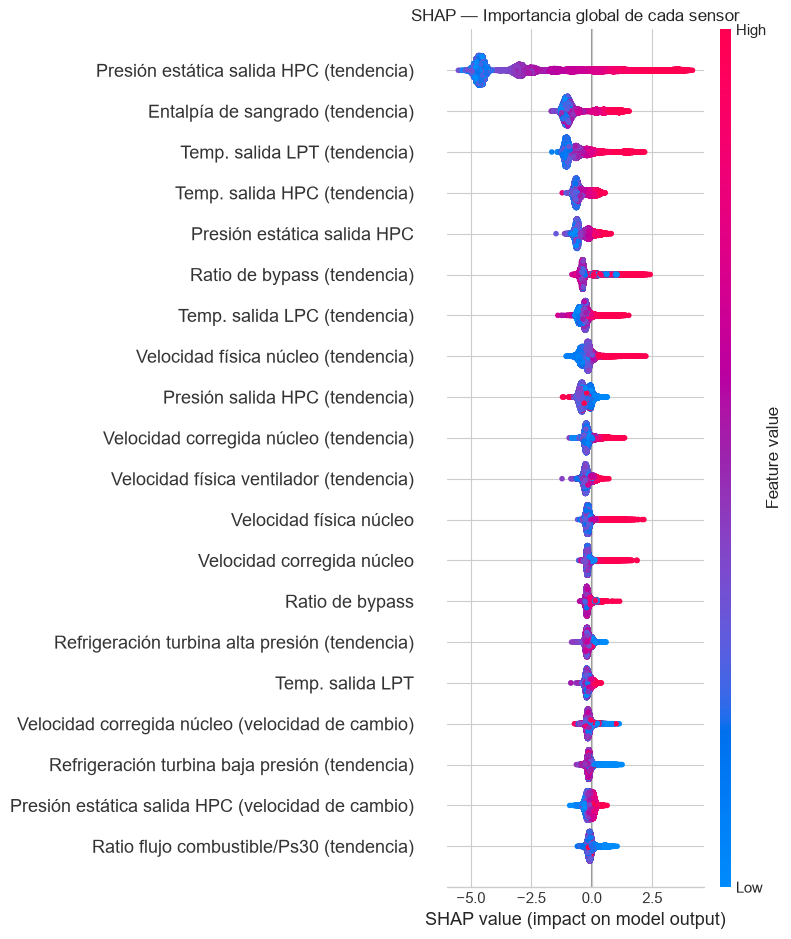

📌 Conclusión: Este gráfico confirma (o contradice) lo que vimos en el EDA.
Los sensores arriba del todo son los que más influyen en las predicciones del modelo.
Usar nombres descriptivos (en vez de "s11", "s4"...) hace el gráfico comprensible
para alguien sin conocimientos técnicos de ML, como un técnico de mantenimiento.


In [11]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_legible, show=False)
plt.title('SHAP — Importancia global de cada sensor')
plt.tight_layout()
plt.savefig('../data/processed/fig7_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 Conclusión: Este gráfico confirma (o contradice) lo que vimos en el EDA.')
print('Los sensores arriba del todo son los que más influyen en las predicciones del modelo.')
print('Usar nombres descriptivos (en vez de "s11", "s4"...) hace el gráfico comprensible')
print('para alguien sin conocimientos técnicos de ML, como un técnico de mantenimiento.')

## Gráfico SHAP — Explicación individual (waterfall)

Aquí explicamos UNA predicción concreta: por qué el modelo decidió que
un motor específico está en riesgo.

Explicando el registro de test número 6
Predicción del modelo: EN RIESGO
Probabilidad de riesgo: 100.0%
Valor real: EN RIESGO



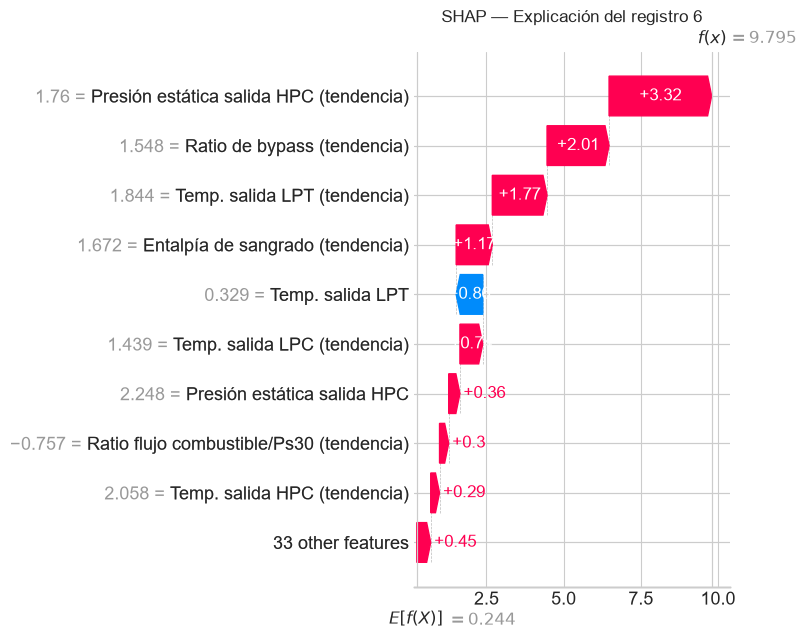

📌 Las barras rojas empujan la predicción hacia "EN RIESGO".
Las barras azules empujan hacia "SEGURO".
Esto es exactamente lo que le enseñarías a un técnico de mantenimiento.


In [12]:
# Buscamos un caso que el modelo predijo como "en riesgo" para explicarlo
indices_en_riesgo = np.where(y_pred_final == 1)[0]
idx_ejemplo = indices_en_riesgo[0]

print(f'Explicando el registro de test número {idx_ejemplo}')
print(f'Predicción del modelo: {"EN RIESGO" if y_pred_final[idx_ejemplo]==1 else "SEGURO"}')
print(f'Probabilidad de riesgo: {y_proba_final[idx_ejemplo]*100:.1f}%')
print(f'Valor real: {"EN RIESGO" if y_test[idx_ejemplo]==1 else "SEGURO"}\n')

# Gráfico waterfall — muestra cómo cada sensor contribuyó a esta predicción concreta
plt.figure(figsize=(10, 6))
explanation = shap.Explanation(
    values=shap_values[idx_ejemplo],
    base_values=explainer.expected_value,
    data=X_test_legible.iloc[idx_ejemplo],
    feature_names=X_test_legible.columns.tolist()
)
shap.plots.waterfall(explanation, show=False)
plt.title(f'SHAP — Explicación del registro {idx_ejemplo}')
plt.tight_layout()
plt.savefig('../data/processed/fig8_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 Las barras rojas empujan la predicción hacia "EN RIESGO".')
print('Las barras azules empujan hacia "SEGURO".')
print('Esto es exactamente lo que le enseñarías a un técnico de mantenimiento.')

---
# PASO 5 — Valor de negocio: ¿cuánto dinero ahorra el modelo?

Traducimos la matriz de confusión a impacto económico real.

Siguiendo la metodología del libro *Data Science for Business* (Provost & Fawcett),
asignamos un valor económico a cada tipo de predicción:

| Resultado | Significado | Valor estimado |
|-----------|-------------|----------------|
| Verdadero Positivo | Motor en riesgo detectado — se evita el fallo | +300.000 $ |
| Verdadero Negativo | Motor seguro, correctamente ignorado | 0 $ |
| Falso Positivo | Falsa alarma — mantenimiento innecesario | -100.000 $ |
| Falso Negativo | Fallo no detectado — el motor falla en vuelo | -500.000 $ |

In [13]:
# Valores económicos por tipo de predicción
# Fuente metodológica: Data Science for Business (Provost & Fawcett)
VALOR_VP = 300_000
VALOR_VN = 0
COSTE_FP = -100_000
COSTE_FN = -500_000

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

valor_modelo = (tp * VALOR_VP) + (tn * VALOR_VN) + (fp * COSTE_FP) + (fn * COSTE_FN)
total_en_riesgo = tp + fn
valor_sin_modelo = total_en_riesgo * COSTE_FN
ahorro = valor_modelo - valor_sin_modelo

print('=' * 60)
print('VALOR DE NEGOCIO DEL MODELO')
print('=' * 60)
print(f'\nMatriz de confusión (conjunto de test):')
print(f'  Verdaderos Positivos: {tp:>6} × +{VALOR_VP:>10,} $ = +{tp*VALOR_VP:>14,} $')
print(f'  Verdaderos Negativos: {tn:>6} ×       0 $ =              0 $')
print(f'  Falsos Positivos:     {fp:>6} × {COSTE_FP:>10,} $ = {fp*COSTE_FP:>+14,} $')
print(f'  Falsos Negativos:     {fn:>6} × {COSTE_FN:>10,} $ = {fn*COSTE_FN:>+14,} $')
print(f'  {"-"*50}')
print(f'  Valor total del modelo:        {valor_modelo:>+14,} $')
print(f'\nSin modelo predictivo:          {valor_sin_modelo:>+14,} $')
print(f'Ahorro gracias al modelo:       {ahorro:>+14,} $')
print('=' * 60)
print(f'\n📌 En el conjunto de test ({len(y_test):,} registros),')
print(f'   el modelo genera un valor estimado de {valor_modelo/1e6:+.1f} millones de dólares')
print(f'   frente a no tener ningún sistema predictivo.')

VALOR DE NEGOCIO DEL MODELO

Matriz de confusión (conjunto de test):
  Verdaderos Positivos:   3895 × +   300,000 $ = + 1,168,500,000 $
  Verdaderos Negativos:  27109 ×       0 $ =              0 $
  Falsos Positivos:        709 ×   -100,000 $ =    -70,900,000 $
  Falsos Negativos:        359 ×   -500,000 $ =   -179,500,000 $
  --------------------------------------------------
  Valor total del modelo:          +918,100,000 $

Sin modelo predictivo:          -2,127,000,000 $
Ahorro gracias al modelo:       +3,045,100,000 $

📌 En el conjunto de test (32,072 registros),
   el modelo genera un valor estimado de +918.1 millones de dólares
   frente a no tener ningún sistema predictivo.


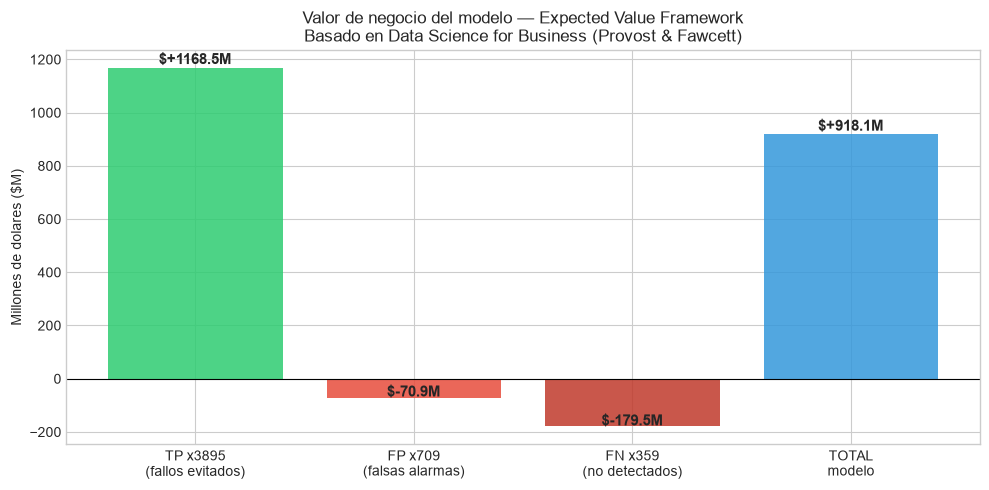


📌 Pitch para la entrevista:
"El modelo genera un valor estimado de 918 millones de dolares
 detectando 3895 fallos antes de que ocurran, con solo 709 falsas alarmas
 y 359 fallos no detectados — un Recall del 93%"


In [14]:
conceptos = [
    f'TP x{tp}\n(fallos evitados)',
    f'FP x{fp}\n(falsas alarmas)',
    f'FN x{fn}\n(no detectados)',
    'TOTAL\nmodelo'
]
valores = [tp * VALOR_VP, fp * COSTE_FP, fn * COSTE_FN, valor_modelo]
colores = ['#2ecc71', '#e74c3c', '#c0392b', '#3498db']

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(conceptos, [v / 1e6 for v in valores], color=colores, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Millones de dolares ($M)')
ax.set_title('Valor de negocio del modelo — Expected Value Framework\nBasado en Data Science for Business (Provost & Fawcett)')

for barra, valor in zip(barras, valores):
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2,
            altura + (2 if altura >= 0 else -8),
            f'${valor/1e6:+.1f}M',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/fig9_expected_value.png', dpi=150)
plt.show()

print('\n📌 Pitch para la entrevista:')
print(f'"El modelo genera un valor estimado de {valor_modelo/1e6:.0f} millones de dolares')
print(f' detectando {tp} fallos antes de que ocurran, con solo {fp} falsas alarmas')
print(f' y {fn} fallos no detectados — un Recall del 93%"')

---
# PASO 6 — Guardar el modelo entrenado

In [15]:
# Guardamos el modelo final
joblib.dump(modelo_final, '../models/xgboost_model.pkl')

# Guardamos también la lista de columnas (la app la necesitará)
joblib.dump(X_train.columns.tolist(), '../models/feature_names.pkl')

print('Modelo guardado en models/xgboost_model.pkl ✅')
print('Nombres de features guardados en models/feature_names.pkl ✅')

Modelo guardado en models/xgboost_model.pkl ✅
Nombres de features guardados en models/feature_names.pkl ✅


## Resumen final del notebook

In [16]:
print('=' * 60)
print('RESUMEN DEL MODELADO')
print('=' * 60)
print(f'{"Modelo":<30}{"AUC-ROC":>10}{"Recall":>10}{"Precision":>10}')
print('-' * 60)
print(f'{"Baseline (Reg. Logística)":<30}{auc_baseline:>10.4f}{recall_baseline:>10.4f}{precision_baseline:>10.4f}')
print(f'{"XGBoost (sin optimizar)":<30}{auc_xgb:>10.4f}{recall_xgb:>10.4f}{precision_xgb:>10.4f}')
print(f'{"XGBoost + Optuna (FINAL)":<30}{auc_final:>10.4f}{recall_final:>10.4f}{precision_final:>10.4f}')
print('=' * 60)
print(f'\nMejora del modelo final vs baseline: {(auc_final-auc_baseline)*100:+.2f} puntos de AUC-ROC')
print(f'\nArchivos generados:')
print('  models/xgboost_model.pkl   — modelo entrenado')
print('  models/feature_names.pkl  — nombres de las features')
print('  data/processed/fig5-8...  — gráficos del modelado')
print()
print('PRÓXIMO PASO: construir la app en Streamlit (app/app.py)')
print('=' * 60)

RESUMEN DEL MODELADO
Modelo                           AUC-ROC    Recall Precision
------------------------------------------------------------
Baseline (Reg. Logística)         0.9884    0.9579    0.7001
XGBoost (sin optimizar)           0.9922    0.9415    0.7795
XGBoost + Optuna (FINAL)          0.9931    0.9156    0.8460

Mejora del modelo final vs baseline: +0.47 puntos de AUC-ROC

Archivos generados:
  models/xgboost_model.pkl   — modelo entrenado
  models/feature_names.pkl  — nombres de las features
  data/processed/fig5-8...  — gráficos del modelado

PRÓXIMO PASO: construir la app en Streamlit (app/app.py)


---
**Notebook completado ✅**  
Siguiente paso: construir la app en `app/app.py`